In [1]:
import polars as pl
import os
import itertools
from matplotlib import pyplot as plt
from multiprocessing_helper import parallel_linkage_attack

In [2]:
data_path = os.path.join("..", "data", "adult", "adult_with_pii.csv")
pii = ["Name", "SSN"]
quasi_identifiers = ["DOB", "Zip", "Age"]
adult = pl.read_csv(data_path, schema_overrides={"Zip": pl.String})
adult_pii = adult.select(pii + quasi_identifiers)
adult_no_pii = adult.drop(pii)

adult_no_pii.describe()

## Classic linkage attack

In [3]:
someone = adult_pii.sample(1)
reidentified = someone.join(adult_no_pii, on=quasi_identifiers)
reidentified

Name,SSN,DOB,Zip,Age,Workclass,fnlwgt,Education,Education-Num,Martial Status,Occupation,Relationship,Race,Sex,Capital Gain,Capital Loss,Hours per week,Country,Target
str,str,str,str,i64,str,i64,str,i64,str,str,str,str,str,i64,i64,i64,str,str
"""Laurie Moynihan""","""324-96-3637""","""3/27/67""","""33352""",53,"""Private""",36327,"""HS-grad""",9,"""Married-civ-spouse""","""Sales""","""Husband""","""White""","""Male""",0,0,40,"""United-States""",""">50K"""


### How many people can be reidentified in this way? Which quasi identifiers are needed?

In [4]:
quasi_id_sets = []
for subset_length in range(1, len(quasi_identifiers) + 1):
    for subset in itertools.combinations(quasi_identifiers, subset_length):
        quasi_id_sets.append(subset)
quasi_id_sets

[('DOB',),
 ('Zip',),
 ('Age',),
 ('DOB', 'Zip'),
 ('DOB', 'Age'),
 ('Zip', 'Age'),
 ('DOB', 'Zip', 'Age')]

In [5]:
people = [frame for frame in adult_pii.iter_slices(1)]
people[0]

Name,SSN,DOB,Zip,Age
str,str,str,str,i64
"""Karrie Trusslove""","""732-14-6110""","""9/7/67""","""64152""",39


In [6]:
reidentification_results = []
for qid_set in quasi_id_sets:
    linkage_attack_args = [(person, adult_no_pii, qid_set) for person in people]
    reidentification_dfs = parallel_linkage_attack(linkage_attack_args)
    successfully_reidentified = 0
    for df in reidentification_dfs:
        if df.shape[0] == 1:
            successfully_reidentified += 1
    reidentification_results.append({
        "quasi_identifiers": qid_set,
        "successfully_reidentified": successfully_reidentified,
        "dfs": reidentification_dfs
    })

{'quasi_identifiers': ('DOB',),
 'successfully_reidentified': 7845,
 'dfs': [shape: (3, 21)
  ┌──────────────┬──────────────┬────────┬───────┬───┬─────────┬──────────────┬─────────────┬────────┐
  │ Name         ┆ SSN          ┆ DOB    ┆ Zip   ┆ … ┆ Capital ┆ Hours per    ┆ Country     ┆ Target │
  │ ---          ┆ ---          ┆ ---    ┆ ---   ┆   ┆ Loss    ┆ week         ┆ ---         ┆ ---    │
  │ str          ┆ str          ┆ str    ┆ str   ┆   ┆ ---     ┆ ---          ┆ str         ┆ str    │
  │              ┆              ┆        ┆       ┆   ┆ i64     ┆ i64          ┆             ┆        │
  ╞══════════════╪══════════════╪════════╪═══════╪═══╪═════════╪══════════════╪═════════════╪════════╡
  │ Karrie       ┆ 732-14-6110  ┆ 9/7/67 ┆ 64152 ┆ … ┆ 0       ┆ 40           ┆ United-Stat ┆ <=50K  │
  │ Trusslove    ┆              ┆        ┆       ┆   ┆         ┆              ┆ es          ┆        │
  │ Karrie       ┆ 732-14-6110  ┆ 9/7/67 ┆ 64152 ┆ … ┆ 0       ┆ 40           ┆ Unit

In [19]:
result_df_args = []
for result in reidentification_results:
    entry = {
        "quasi_identifiers": str.join(",", result["quasi_identifiers"]),
        "success_rate": result["successfully_reidentified"]/adult_pii.shape[0]
    }
    result_df_args.append(entry)
reidentification_df = pl.DataFrame(result_df_args, strict=False)
reidentification_df

quasi_identifiers,success_rate
str,f64
"""DOB""",0.240932
"""Zip""",0.722122
"""Age""",0.000061
"""DOB,Zip""",0.999939
"""DOB,Age""",0.969258
"""Zip,Age""",0.994042
"""DOB,Zip,Age""",1.0


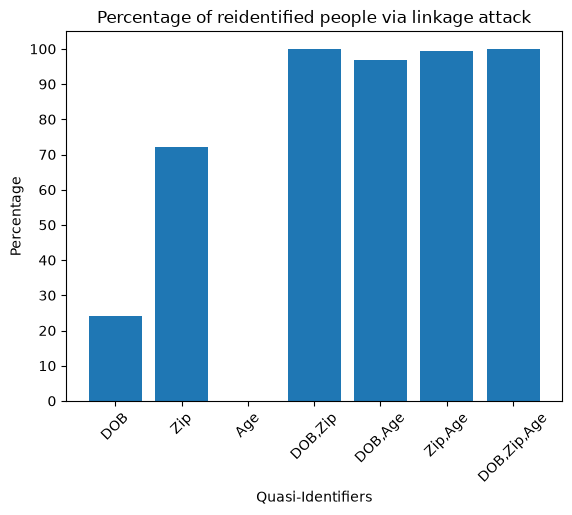

In [43]:
import numpy as np
plt.bar(reidentification_df["quasi_identifiers"], reidentification_df["success_rate"]*100)
plt.xticks(rotation=45)
plt.yticks(np.arange(0, 101, 10))
plt.title("Percentage of reidentified people via linkage attack")
plt.ylabel("Percentage")
plt.xlabel("Quasi-Identifiers")
plt.show()